# 02 - Deep Q-Learning su LunarLander

Questo notebook applica DQN a `LunarLander-v3`, usando replay buffer e target network per stabilizzare il bootstrap TD. Rispetto a CartPole, LunarLander richiede piu' esplorazione e una valutazione qualitativa del comportamento, perche' reward simili possono corrispondere a traiettorie di atterraggio molto diverse.


## Setup

In [1]:
from pathlib import Path
import sys

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from torch.optim import Adam

current_path = Path.cwd().resolve()
project_root = current_path
for candidate in [current_path, *current_path.parents]:
    if (candidate / "DLA_LAB3").exists():
        project_root = candidate
        break

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from DLA_LAB3.src.dqn import evaluate_q_policy, render_q_policy, train_dqn, train_vectorized_dqn
from DLA_LAB3.src.networks import QNetwork
from DLA_LAB3.src.plotting import plot_seed_eval_curves
from DLA_LAB3.src.utils import get_device, make_vector_env, restore_model_state, seed_environment, set_seed

In [2]:
config_path = project_root / "DLA_LAB3" / "exercise_3_2_dql" / "config_lunarlander.yaml"
with config_path.open("r", encoding="utf-8") as file:
    raw_config = yaml.safe_load(file)

CONFIG = {
    "environment_name": raw_config["environment"]["name"],
    "max_steps": raw_config["environment"]["max_steps"],
    "seeds": raw_config["training"]["seeds"],
    "num_episodes": raw_config["training"]["num_episodes"],
    "gamma": raw_config["training"]["gamma"],
    "learning_rate": raw_config["training"]["learning_rate"],
    "hidden_dim": raw_config["training"]["hidden_dim"],
    "batch_size": raw_config["training"]["batch_size"],
    "replay_capacity": raw_config["training"]["replay_capacity"],
    "min_replay_size": raw_config["training"]["min_replay_size"],
    "train_every_steps": raw_config["training"]["train_every_steps"],
    "gradient_steps": raw_config["training"].get("gradient_steps", 1),
    "vectorized": raw_config["training"].get("vectorized", False),
    "num_envs": raw_config["training"].get("num_envs", 1),
    "vector_env_type": raw_config["training"].get("vector_env_type", "sync"),
    "target_update_every_steps": raw_config["training"]["target_update_every_steps"],
    "epsilon_start": raw_config["training"]["epsilon_start"],
    "epsilon_end": raw_config["training"]["epsilon_end"],
    "epsilon_decay_steps": raw_config["training"]["epsilon_decay_steps"],
    "gradient_clip": raw_config["training"]["gradient_clip"],
    "evaluation_episodes": raw_config["evaluation"]["num_episodes"],
    "eval_every_n": raw_config["evaluation"]["eval_every_n"],
    "eval_episodes_m": raw_config["evaluation"]["eval_episodes_m"],
}

set_seed(CONFIG["seeds"][0])
device = get_device(force_cpu=raw_config["training"]["force_cpu"])
device

device(type='cpu')

## Ambiente LunarLander

In [3]:
env = gym.make(CONFIG["environment_name"])
observation, _ = seed_environment(env, CONFIG["seeds"][0])

observation_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("Observation iniziale:", observation)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation dim:", observation_dim)
print("Action dim:", action_dim)

Observation iniziale: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Observation dim: 8
Action dim: 4


## Training

Addestro una Q-network indipendente per ogni seed configurato, usando replay buffer e target network. La configurazione corrente usa ambienti vettorializzati: piu' copie indipendenti di LunarLander raccolgono transizioni in parallelo e le inseriscono nello stesso replay buffer.

Durante la valutazione periodica salvo in memoria il miglior checkpoint della Q-network e lo ripristino prima della valutazione finale. Questo evita di giudicare l'algoritmo sull'ultimo stato del training, che in DQN puo' degradare dopo aver raggiunto una buona policy.


In [4]:
# Conserviamo una Q-network finale per seed insieme alle relative metriche.
training_results = {}
trained_networks = {}
final_rows = []

for seed in CONFIG["seeds"]:
    print(f"Run seed {seed}")
    set_seed(seed)

    # Gli ambienti paralleli alimentano lo stesso replay buffer condiviso.
    use_vectorized_training = CONFIG["vectorized"] and CONFIG["num_envs"] > 1
    if use_vectorized_training:
        train_env = make_vector_env(
            environment_name=CONFIG["environment_name"],
            seed=seed,
            num_envs=CONFIG["num_envs"],
            vector_env_type=CONFIG["vector_env_type"],
        )
    else:
        train_env = gym.make(CONFIG["environment_name"])
        seed_environment(train_env, seed)

    eval_env_inter = gym.make(CONFIG["environment_name"])
    seed_environment(eval_env_inter, seed + 10_000)

    q_network = QNetwork(
        observation_dim=observation_dim,
        action_dim=action_dim,
        hidden_dim=CONFIG["hidden_dim"],
    ).to(device)
    target_network = QNetwork(
        observation_dim=observation_dim,
        action_dim=action_dim,
        hidden_dim=CONFIG["hidden_dim"],
    ).to(device)
    optimizer = Adam(q_network.parameters(), lr=CONFIG["learning_rate"])

    if use_vectorized_training:
        training_result = train_vectorized_dqn(
            envs=train_env,
            q_network=q_network,
            target_network=target_network,
            optimizer=optimizer,
            device=device,
            num_episodes=CONFIG["num_episodes"],
            gamma=CONFIG["gamma"],
            max_steps=CONFIG["max_steps"],
            batch_size=CONFIG["batch_size"],
            replay_capacity=CONFIG["replay_capacity"],
            min_replay_size=CONFIG["min_replay_size"],
            train_every_steps=CONFIG["train_every_steps"],
            gradient_steps=CONFIG["gradient_steps"],
            target_update_every_steps=CONFIG["target_update_every_steps"],
            epsilon_start=CONFIG["epsilon_start"],
            epsilon_end=CONFIG["epsilon_end"],
            epsilon_decay_steps=CONFIG["epsilon_decay_steps"],
            gradient_clip=CONFIG["gradient_clip"],
            eval_env=eval_env_inter,
            eval_every_n=CONFIG["eval_every_n"],
            eval_episodes_m=CONFIG["eval_episodes_m"],
        )
    else:
        training_result = train_dqn(
            env=train_env,
            q_network=q_network,
            target_network=target_network,
            optimizer=optimizer,
            device=device,
            num_episodes=CONFIG["num_episodes"],
            gamma=CONFIG["gamma"],
            max_steps=CONFIG["max_steps"],
            batch_size=CONFIG["batch_size"],
            replay_capacity=CONFIG["replay_capacity"],
            min_replay_size=CONFIG["min_replay_size"],
            train_every_steps=CONFIG["train_every_steps"],
            target_update_every_steps=CONFIG["target_update_every_steps"],
            epsilon_start=CONFIG["epsilon_start"],
            epsilon_end=CONFIG["epsilon_end"],
            epsilon_decay_steps=CONFIG["epsilon_decay_steps"],
            gradient_clip=CONFIG["gradient_clip"],
            eval_env=eval_env_inter,
            eval_every_n=CONFIG["eval_every_n"],
            eval_episodes_m=CONFIG["eval_episodes_m"],
        )
    train_env.close()
    eval_env_inter.close()

    # Ripristiniamo il checkpoint scelto sulla valutazione periodica, non l'ultimo update.
    restore_model_state(q_network, training_result.best_q_state)
    restore_model_state(target_network, training_result.best_target_state)

    # Un seed distinto separa la valutazione finale da training e selezione del checkpoint.
    final_eval_env = gym.make(CONFIG["environment_name"])
    seed_environment(final_eval_env, seed + 20_000)
    final_eval = evaluate_q_policy(
        env=final_eval_env,
        q_network=q_network,
        device=device,
        num_episodes=CONFIG["evaluation_episodes"],
        max_steps=CONFIG["max_steps"],
    )
    final_eval_env.close()

    training_results[seed] = training_result
    trained_networks[seed] = q_network
    row = {
        "Seed": seed,
        "Final Train Reward": round(training_result.episode_rewards[-1], 1),
        "Best Train Reward": round(max(training_result.episode_rewards), 1),
        "Eval Mean Reward": round(final_eval["mean_reward"], 1),
        "Eval Min Reward": round(final_eval["min_reward"], 1),
        "Eval Max Reward": round(final_eval["max_reward"], 1),
        "Eval Mean Length": round(final_eval["mean_length"], 1),
        "Best Checkpoint Episode": training_result.best_eval_episode,
        "Best Checkpoint Reward": round(training_result.best_eval_mean_reward, 1),
    }
    final_rows.append(row)
    print(row)

results_table = pd.DataFrame(final_rows)
display(results_table)

best_seed = int(results_table.sort_values("Eval Mean Reward", ascending=False).iloc[0]["Seed"])
print(f"Seed migliore in valutazione: {best_seed}")

Run seed 42
{'Seed': 42, 'Final Train Reward': 291.7, 'Best Train Reward': 323.7, 'Eval Mean Reward': 284.4, 'Eval Min Reward': 237.0, 'Eval Max Reward': 314.4, 'Eval Mean Length': 214.9, 'Best Checkpoint Episode': 1500, 'Best Checkpoint Reward': 285.0}
Run seed 123
{'Seed': 123, 'Final Train Reward': 2.3, 'Best Train Reward': 324.6, 'Eval Mean Reward': 275.2, 'Eval Min Reward': 245.9, 'Eval Max Reward': 298.7, 'Eval Mean Length': 199.7, 'Best Checkpoint Episode': 1000, 'Best Checkpoint Reward': 273.4}
Run seed 314
{'Seed': 314, 'Final Train Reward': 290.4, 'Best Train Reward': 323.8, 'Eval Mean Reward': 262.3, 'Eval Min Reward': 140.0, 'Eval Max Reward': 304.2, 'Eval Mean Length': 267.9, 'Best Checkpoint Episode': 950, 'Best Checkpoint Reward': 269.0}


,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward
0,42,291.7,323.7,284.4,237.0,314.4,214.9,1500,285.0
1,123,2.3,324.6,275.2,245.9,298.7,199.7,1000,273.4
2,314,290.4,323.8,262.3,140.0,304.2,267.9,950,269.0


Seed migliore in valutazione: 42


## Curve di valutazione periodica

La curva di training mostra reward stocastici raccolti durante l'esplorazione epsilon-greedy. La curva di valutazione, invece, usa una policy deterministica e misura la qualita' del comportamento senza aggiornare i pesi. Per LunarLander considero rilevanti sia il reward medio sia la stabilita' degli episodi peggiori.


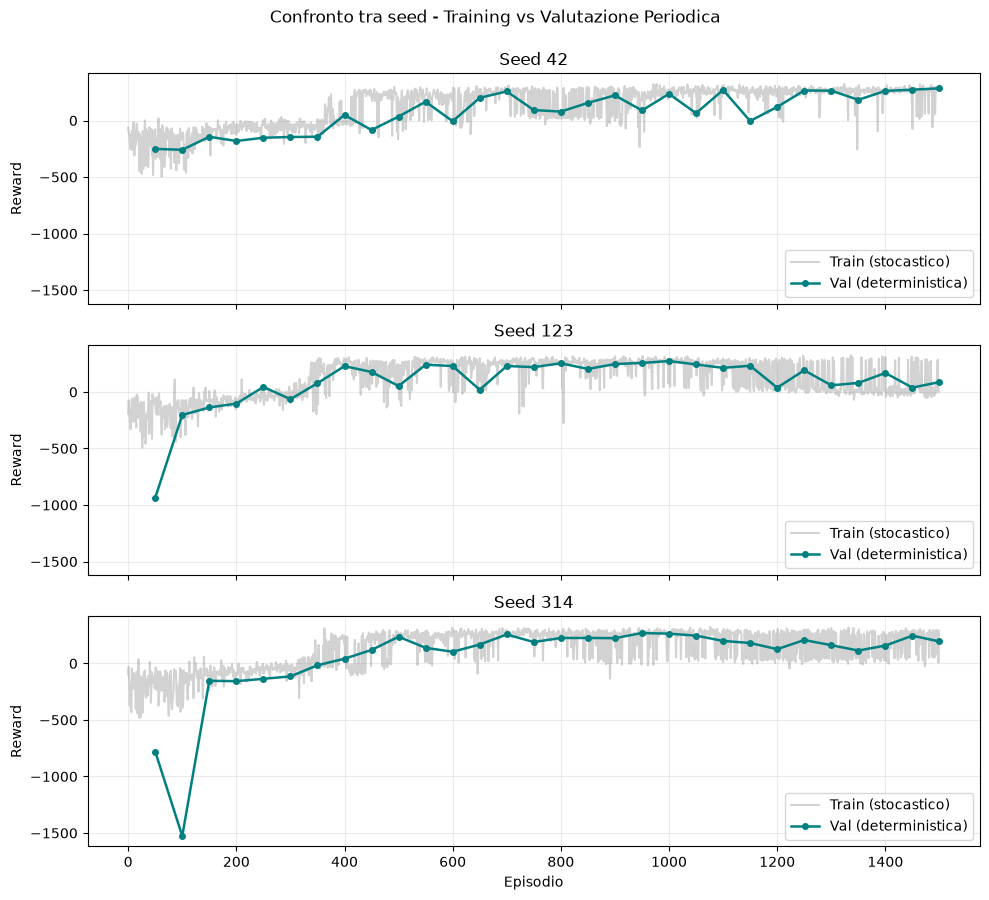

In [5]:
plot_seed_eval_curves(
    {
        seed: {
            "train_rewards": result.episode_rewards,
            "eval_intervals": result.eval_episodes or [],
            "eval_rewards": result.eval_mean_rewards or [],
        }
        for seed, result in training_results.items()
    }
)

## Loss DQN

La loss DQN misura l'errore temporale medio sui batch estratti dal replay buffer. In LunarLander puo' restare rumorosa anche quando la policy migliora, quindi va letta insieme alla valutazione periodica e al rendering. Una loss piu' bassa non garantisce automaticamente un atterraggio piu' pulito.


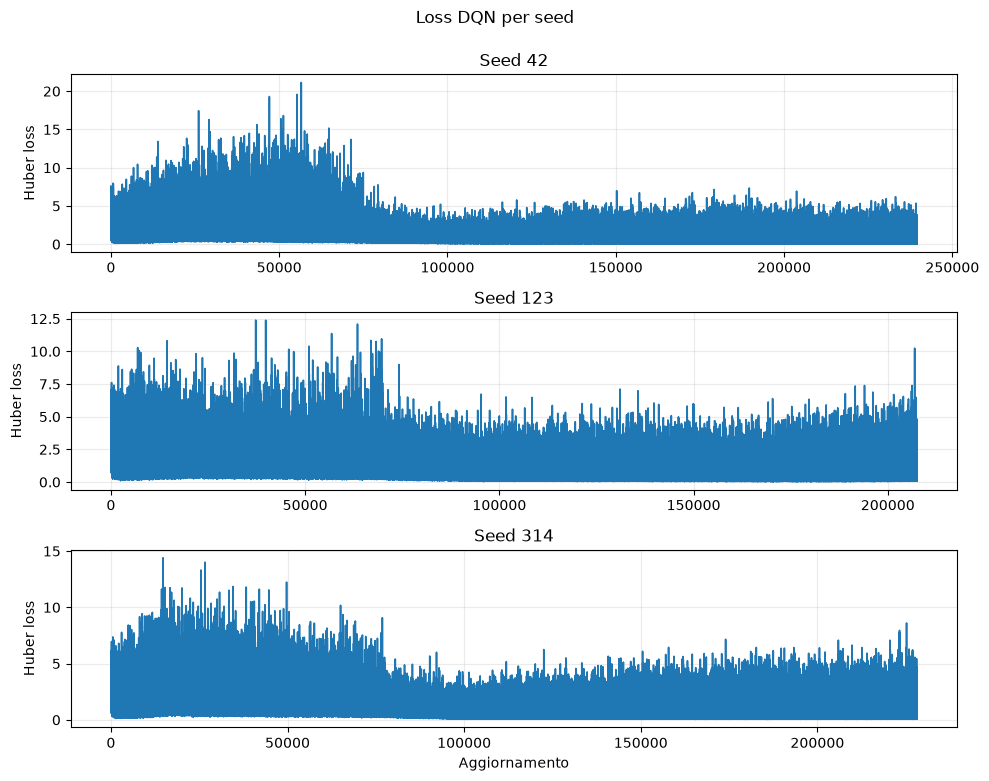

In [6]:
fig, axes = plt.subplots(
    len(training_results),
    1,
    figsize=(10, 2.6 * len(training_results)),
    sharex=False,
)

if len(training_results) == 1:
    axes = [axes]

for axis, (seed, result) in zip(axes, training_results.items()):
    axis.plot(result.losses, linewidth=1.2, color="tab:blue")
    axis.set_title(f"Seed {seed}")
    axis.set_ylabel("Huber loss")
    axis.grid(alpha=0.25)

axes[-1].set_xlabel("Aggiornamento")
fig.suptitle("Loss DQN per seed", y=0.995)
fig.tight_layout()
plt.show()

## Risultati aggregati

La tabella aggregata usa la valutazione deterministica del miglior checkpoint ripristinato per ciascuno dei tre seed.

Con la configurazione vettorializzata corrente (`num_envs=8`, `gradient_steps=4`, `epsilon_decay_steps=70000`, `target_update_every_steps=1000`) il reward medio aggregato e' `274.0 ± 11.1`. Le medie dei tre seed vanno da `262.3` a `284.4` e restano tutte sopra la soglia di 200; il minimo globale osservato nei 60 episodi finali e' `140.0`.


In [7]:
aggregated_table = results_table[
    ["Eval Mean Reward", "Eval Min Reward", "Eval Max Reward", "Eval Mean Length"]
].agg(["mean", "std", "min", "max"])
display(aggregated_table)

,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length
mean,273.966667,207.633333,305.766667,227.500000
std,11.101501,58.740985,7.966388,35.803352
min,262.300000,140.000000,298.700000,199.700000
max,284.400000,245.900000,314.400000,267.900000


## Visualizzazione real time

Renderizzo la Q-policy ripristinata dal miglior checkpoint di valutazione. La visualizzazione serve come controllo qualitativo del comportamento appreso e non modifica i pesi del modello. In LunarLander questo controllo e' importante per verificare che l'agente non ottenga reward buoni con manovre inutilmente aggressive, come una picchiata seguita da una lunga correzione finale.


In [8]:
render_rewards = render_q_policy(
    environment_name=CONFIG["environment_name"],
    q_network=trained_networks[best_seed],
    device=device,
    num_episodes=3,
    max_steps=CONFIG["max_steps"],
    frame_delay=0.02,
)
render_rewards

[244.9276600887439, 282.4931691836898, 292.61919186539967]

In [9]:
env.close()